# 01 · Data overview & the target problem

The Siburg compilation: **336** flat-slab punching tests from **55** labs. This notebook does the EDA *and* establishes the single most important decision in the rebuild: **what to predict.**

The original study predicted the absolute failure **load** `V_test` [MN]. But punching capacity is `V = v · u₁ · d` — load is mechanically proportional to the control area `u₁·d`. So regressing load on the effective depth `d` mostly relearns a trivial size effect. We instead predict the punching **stress** `v = V/(u₁·d)` [MPa].

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import punching_shear as ps
REPO = Path(ps.__file__).resolve().parent.parent
RESULTS = REPO / 'results'
ds = ps.load_dataset()
print(f'{len(ds)} tests, {ds.groups.nunique()} researchers, features={ds.feature_names}')

336 tests, 55 researchers, features=['d', 'col_area', 'rho_l', 'fcm_cyl', 'u0_perim']


### Features and targets

In [2]:
display(ds.X.describe().T.round(2))
print('Primary target  v_test [MPa]:', ds.y_stress.describe()[['min','50%','max']].round(3).to_dict())
print('Original target V_test [MN]:', ds.y_load.describe()[['min','50%','max']].round(3).to_dict())

,count,mean,std,min,25%,50%,75%,max
d,336.0,121.98,65.82,30.00,86.00,109.00,127.25,500.00
col_area,336.0,49535.95,71268.75,2042.82,17478.59,32047.39,64516.00,637587.01
rho_l,336.0,1.32,0.71,0.22,0.80,1.18,1.53,5.01
fcm_cyl,336.0,36.10,21.06,9.40,23.80,29.35,38.95,125.00
u0_perim,336.0,1.56,0.74,0.23,0.97,1.57,1.83,5.70


Primary target  v_test [MPa]: {'min': 0.561, '50%': 1.533, 'max': 3.272}
Original target V_test [MN]: {'min': 0.025, '50%': 0.314, 'max': 2.681}


### Missingness (why we model only 5 features)
`dg`, `fym`, `Esm`, `c2` are heavily missing, so they are dropped; the five modelling features are fully observed.

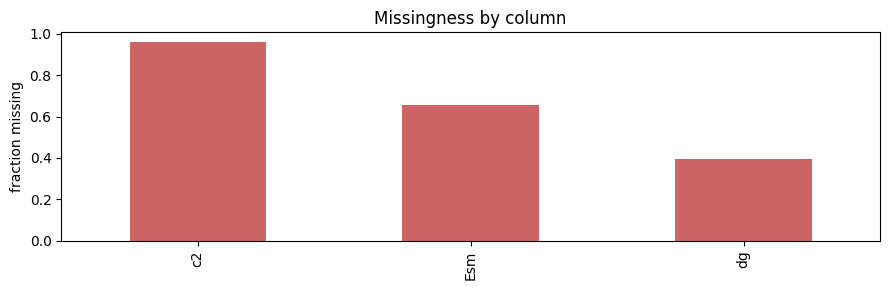

core features missing: 0


In [3]:
raw = ds.raw
miss = raw.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0]
ax = miss.plot.bar(figsize=(9,3), color='#c66'); ax.set_ylabel('fraction missing')
ax.set_title('Missingness by column'); plt.tight_layout(); plt.show()
print('core features missing:', int(ds.X.isna().sum().sum()))

### Collinearity

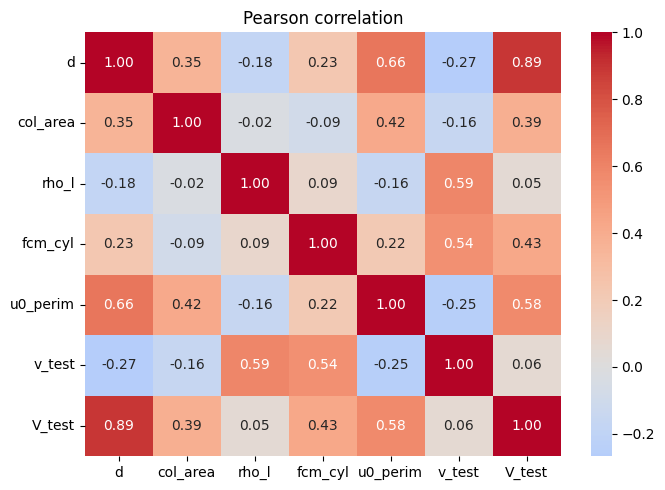

In [4]:
import seaborn as sns
M = ds.X.copy(); M['v_test']=ds.y_stress; M['V_test']=ds.y_load
plt.figure(figsize=(7,5)); sns.heatmap(M.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Pearson correlation'); plt.tight_layout(); plt.show()

## The central issue: load vs stress
Single-feature R² of each predictor against **load** and against **stress**.

target,load V_test,stress v
feature,,
col_area,0.151,0.025
d,0.798,0.071
fcm_cyl,0.183,0.292
rho_l,0.003,0.349
u0_perim,0.331,0.065


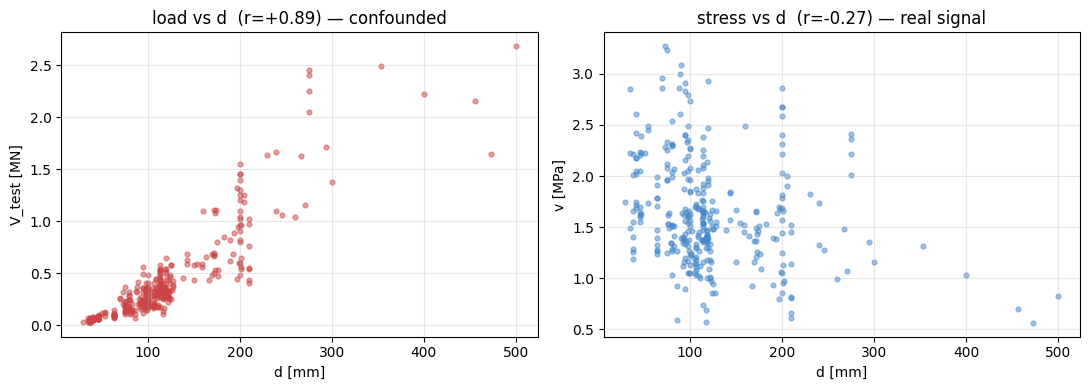

In [5]:
rows=[]
for tgt,name in [(ds.y_load,'load V_test'),(ds.y_stress,'stress v')]:
    for f in ds.feature_names:
        r=np.corrcoef(ds.X[f],tgt)[0,1]; rows.append({'feature':f,'target':name,'R2':r**2})
tab=pd.DataFrame(rows).pivot(index='feature',columns='target',values='R2').round(3)
display(tab)
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].scatter(ds.X['d'],ds.y_load,s=12,alpha=.5,c='#c44'); ax[0].set_title(f"load vs d  (r={np.corrcoef(ds.X['d'],ds.y_load)[0,1]:+.2f}) — confounded"); ax[0].set_xlabel('d [mm]'); ax[0].set_ylabel('V_test [MN]')
ax[1].scatter(ds.X['d'],ds.y_stress,s=12,alpha=.5,c='#48c'); ax[1].set_title(f"stress vs d  (r={np.corrcoef(ds.X['d'],ds.y_stress)[0,1]:+.2f}) — real signal"); ax[1].set_xlabel('d [mm]'); ax[1].set_ylabel('v [MPa]')
[a.grid(alpha=.3) for a in ax]; plt.tight_layout(); plt.show()

**Takeaway.** Against **load**, `d` looks all-important (R²≈0.80). Against **stress**, `d` explains almost nothing (R²≈0.07) and the real drivers are the reinforcement ratio `rho_l` and concrete strength `fcm_cyl` — exactly what punching mechanics predicts. Everything downstream targets stress.